# Classification des œuvres de Zola et d'autres naturalistes

## Expérience avec retrait d'une liste de noms propres

## 1. Importation des bibliothèques

In [1]:
# Fichiers et données
import os
import glob
import json
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.metrics import (accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
print("Toutes les bibliothèques sont chargées.")


Toutes les bibliothèques sont chargées.


## 2. Normalisation des apostrophes

Les textes ayant été préalablement nettoyés, certaines apostrophes ont
disparu. Cette étape restaure les contractions les plus fréquentes à partir
d'un dictionnaire de correspondances.

N.b: Les formes `dune` et `lune` sont respectivement interprétées comme `d'une`
et `l'une`. Ce choix repose sur l'hypothèse que les occurrences des noms
communs *dune* et *lune* sont minoritaires dans le corpus étudié.

In [2]:
REMPLACEMENTS_APOSTROPHES = {
    # ========================================================
    # Locutions longues : à traiter avant les formes courtes
    # ========================================================
    "lorsquil": "lorsqu'il",
    "lorsquils": "lorsqu'ils",
    "lorsquon": "lorsqu'on",
    "lorsquune": "lorsqu'une",
    "lorsquun": "lorsqu'un",
    "lorsquelle": "lorsqu'elle",
    "lorsquelles": "lorsqu'elles",

    "puisquil": "puisqu'il",
    "puisquils": "puisqu'ils",
    "puisquon": "puisqu'on",
    "puisquune": "puisqu'une",
    "puisquun": "puisqu'un",
    "puisquelle": "puisqu'elle",
    "puisquelles": "puisqu'elles",

    "quoiquil": "quoiqu'il",
    "quoiquils": "quoiqu'ils",
    "quoiquon": "quoiqu'on",
    "quoiquelle": "quoiqu'elle",

    "jusquil": "jusqu'il",
    "jusquils": "jusqu'ils",
    "jusquon": "jusqu'on",
    "jusquune": "jusqu'une",
    "jusquun": "jusqu'un",
    "jusquelle": "jusqu'elle",
    "jusquelles": "jusqu'elles",
    "jusquà": "jusqu'à",
    "jusquau": "jusqu'au",
    "jusquaux": "jusqu'aux",

    # ========================================================
    # Contractions avec c'
    # ========================================================
    "cest": "c'est",
    "cétait": "c'était",
    "cétaient": "c'étaient",
    "cétant": "c'étant",
    "cen": "c'en",

    # ========================================================
    # Contractions avec s'
    # ========================================================
    "sest": "s'est",
    "sétait": "s'était",
    "sétaient": "s'étaient",
    "sétant": "s'étant",
    "sen": "s'en",
    "sy": "s'y",
    "sil": "s'il",
    "sils": "s'ils",

    # ========================================================
    # Contractions avec n'
    # ========================================================
    "nest": "n'est",
    "nétait": "n'était",
    "nétaient": "n'étaient",
    "navait": "n'avait",
    "navaient": "n'avaient",
    "naurait": "n'aurait",
    "nauraient": "n'auraient",
    "naura": "n'aura",
    "nauront": "n'auront",
    "na": "n'a",
    "nont": "n'ont",
    "nen": "n'en",
    "ny": "n'y",
    "navoir": "n'avoir",
    "nêtre": "n'être",
    "nai": "n'ai",
    "navez": "n'avez",

    # ========================================================
    # Contractions avec j'
    # ========================================================
    "jai": "j'ai",
    "javais": "j'avais",
    "jétais": "j'étais",
    "jaurais": "j'aurais",
    "jaurai": "j'aurai",
    "jaime": "j'aime",
    "jallais": "j'allais",
    "jignore": "j'ignore",
    "jentends": "j'entends",
    "jen": "j'en",
    "jy": "j'y",
    "jirai": "j'irai",
    "tai": "t'ai",

    # ========================================================
    # Contractions avec qu'
    # ========================================================
    "quest": "qu'est",
    "quil": "qu'il",
    "quils": "qu'ils",
    "quon": "qu'on",
    "quun": "qu'un",
    "quune": "qu'une",
    "quà": "qu'à",
    "quen": "qu'en",


    # ========================================================
    # Contractions avec d'
    # ========================================================
    "dune": "d'une", #je prend le parti de mettre d'apostrophe mais il y a un risque de confusion avec "d'une" (de une) et "dune" (la dune) 
    "dun": "d'un",
    "delle": "d'elle",
    "delles": "d'elles",
    "dêtre": "d'être",
    "davoir": "d'avoir",
    "dabord": "d'abord",
    "dailleurs": "d'ailleurs",
    "daprès": "d'après",
    "daccord": "d'accord",
    "davance": "d'avance",
    "doù": "d'où",
    "dautres": "d'autres",
    "damour": "d'amour",
    "dargent": "d'argent",
    "despoir": "d'espoir",
    "den": "d'en",
    "desprit": "d'esprit",
    'deau': "d'eau",

    # ========================================================
    # Contractions avec l'
    # ========================================================
    "labbé": "l'abbé",
    "lair": "l'air",
    "lâme": "l'âme",
    "lami": "l'ami",
    "lamie": "l'amie",
    "lamour": "l'amour",
    "largent": "l'argent",
    "lautre": "l'autre",
    "lun": "l'un",
    "lune": "l'une",
    "lheure": "l'heure",
    "lhomme": "l'homme",
    "lhonneur": "l'honneur",
    "lhistoire": "l'histoire",
    "lhôtel": "l'hôtel",
    "léglise": "l'église",
    "lépoque": "l'époque",
    "lenfant": "l'enfant",
    "lendroit": "l'endroit",
    "lentrée": "l'entrée",
    "lintérieur": "l'intérieur",
    "lidée": "l'idée",
    "lombre": "l'ombre",
    "loeil": "l'œil",
    "lœil": "l'œil",
    "lon": "l'on",
    "lai": "l'ai",
    "lavait": "l'avait",
    "leau": "l'eau",
    "lesprit": "l'esprit",
    "lescalier": "l'escalier",
    "létudiant": "l'étudiant",
    'lavenir': "l'avenir",
    "laffaire": "l'affaire",
    "loreille": "l'oreille",
    "lavocat": "l'avocat",

    # ========================================================
    # Locutions courantes
    # ========================================================
    "aujourdhui": "aujourd'hui",
    "presquun": "presqu'un",
    "presquune": "presqu'une",
    "quelquun": "quelqu'un",
    "quelquune": "quelqu'une",
    "quaprès": "qu'après",

    # ========================================================
    # Verbes pronominaux fréquemment rencontrés
    # ========================================================
    "sécria": "s'écria",
    "sécriait": "s'écriait",
    "sécrièrent": "s'écrièrent",
    "saperçut": "s'aperçut",
    "sapercevait": "s'apercevait",
    "sapprocha": "s'approcha",
    "sapprochait": "s'approchait",
    "sarrêta": "s'arrêta",
    "sarrêtait": "s'arrêtait",
    "sassit": "s'assit",
    "sétendit": "s'étendit",
    "séloigna": "s'éloigna",
    "séloignait": "s'éloignait",
    "sêtre" : "s'être",
    
    # m'
    "men": "m'en",
    "mavez": "m'avez",
    "mavait": "m'avait",
    
    "daller": "d'aller",
    "lappartement": "l'appartement",
    "lhuile": "l'huile",
    "mest": "m'est",
    "dhonneur": "d'honneur",
    "dici": "d'ici",
    "neût": "n'eût",
    "sécrie": "s'écrie",
    "ce quelle": "ce qu'elle",
    "ten": "t'en",
    "dhenriette": "d'Henriette",
    "lart": "l'art",
    "quau": "qu'au",
    "quaux": "qu'aux",
    "dautre": "d'autre",
    "dautres": "d'autres",
    "navais": "n'avais",
    "navions": "n'avions",
    "sagit": "s'agit",
    
    "dœil": "d'œil", 
    "létat": "l'état", 
    "leffet": "l'effet", 
    "jespère": "j'espère", 
    "lhabitude": "l'habitude", 
    "nêtes": "n'êtes",
    "dy": "d'y",
    "linstant": "l'instant",
    "nimporte": "n'importe",
    
    
    #=============================
    #Artecfact OCR
    #=============================
    "jé":"je",
    "dé":"de", 
    "lé": "le", 
    "mé":"me", 
    "cé":"ce", 
    "qué":"que",
    "dor": "d'or", 
    "my": "m'y", 
    "ten": "t'en",
    "daffaires": "d'affaires",
    "daimer": "d'aimer",
    "dair": "d'air",
    "dangoisse": "d'angoisse",
    "dannées": "d'années",
    "darbres": "d'arbres",
    "darmes": "d'armes",
    "darriver": "d'arriver",
    "dart": "d'art",
    "dattendre": "d'attendre",
    "dautant": "d'autant",
    "dautrefois": "d'autrefois",
    "denfant": "d'enfant",
    "denfants": "d'enfants",
    "dentendre": "d'entendre",
    "dentrer": "d'entrer",
    "dhabitude": "d'habitude",
    "dheure": "d'heure",
    "dhomme": "d'homme",
    "dhommes": "d'hommes",
    "didées": "d'idées",
    "dimpatience": "d'impatience",
    "dinquiétude": "d'inquiétude",
    "douvrir": "d'ouvrir",
    "dénormes": "d'énormes",
    "dété": "d'été",
    "dœuvre": "d'œuvre",
    "jaimerais": "j'aimerais",
    "labri": "l'abri",
    "lacte": "l'acte",
    "laction": "l'action",
    "ladresse": "l'adresse",
    "laimait": "l'aimait",
    "laime": "l'aime",
    "laimer": "l'aimer",
    "laise": "l'aise",
    "lallée": "l'allée",
    "lamant": "l'amant",
    "lamitié": "l'amitié",
    "lancien": "l'ancien",
    "lancienne": "l'ancienne",
    "lannée": "l'année",
    "lantichambre": "l'antichambre",
    "lappelait": "l'appelait",
    "laprès": "l'après",
    "larrivée": "l'arrivée",
    "larrière": "l'arrière",
    "larrêta": "l'arrêta",
    "lartiste": "l'artiste",
    "laspect": "l'aspect",
    "lattaque": "l'attaque",
    "lattendait": "l'attendait",
    "lattente": "l'attente",
    "lattention": "l'attention",
    "lattitude": "l'attitude",
    "lauberge": "l'auberge",
    "laurais": "l'aurais",
    "laurait": "l'aurait",
    "lauteur": "l'auteur",
    "laventure": "l'aventure",
    "layant": "l'ayant",
    "lembarras": "l'embarras",
    "lembrassa": "l'embrassa",
    "lembrasser": "l'embrasser",
    "lennemi": "l'ennemi",
    "lennui": "l'ennui",
    "lentendre": "l'entendre",
    "lentretien": "l'entretien",
    "lenvie": "l'envie",
    "lespace": "l'espace",
    "lespoir": "l'espoir",
    "lespérance": "l'espérance",
    "lestomac": "l'estomac",
    "lexistence": "l'existence",
    "lexpression": "l'expression",
    "lexpérience": "l'expérience",
    "leût": "l'eût",
    "lherbe": "l'herbe",
    "lhiver": "l'hiver",
    "lhorizon": "l'horizon",
    "lhorreur": "l'horreur",
    "lhumanité": "l'humanité",
    "limage": "l'image",
    "limagination": "l'imagination",
    "limmense": "l'immense",
    "limpression": "l'impression",
    "linconnu": "l'inconnu",
    "linfluence": "l'influence",
    "linquiétude": "l'inquiétude",
    "linstinct": "l'instinct",
    "lintelligence": "l'intelligence",
    "linterrompit": "l'interrompit",
    "lintérêt": "l'intérêt",
    "lobscurité": "l'obscurité",
    "loccasion": "l'occasion",
    "lont": "l'ont",
    "lopinion": "l'opinion",
    "lopéra": "l'opéra",
    "lor": "l'or",
    "lorage": "l'orage",
    "lordre": "l'ordre",
    "louvrage": "l'ouvrage",
    "lusage": "l'usage",
    "ly": "l'y",
    "lâge": "l'âge",
    "léclat": "l'éclat",
    "lécole": "l'école",
    "lécoutait": "l'écoutait",
    "léducation": "l'éducation",
    "lémotion": "l'émotion",
    "lépaule": "l'épaule",
    "létoffe": "l'étoffe",
    "létranger": "l'étranger",
    "létude": "l'étude",
    "lété": "l'été",
    "lêtre": "l'être",
    "lœuvre": "l'œuvre",
    "maime": "m'aime",
    "naimait": "n'aimait",
    "naime": "n'aime",
    "naurais": "n'aurais",
    "navons": "n'avons",
    "nayant": "n'ayant",
    "nentendait": "n'entendait",
    "neut": "n'eut",
    "nosa": "n'osa",
    "nosait": "n'osait",
    "nosant": "n'osant",
    "nétais": "n'étais",
    "nétant": "n'étant",
    "quavait": "qu'avait",
    "quavec": "qu'avec",
    "quy": "qu'y",
    "sadressant": "s'adressant",
    "sagissait": "s'agissait",
    "samusait": "s'amusait",
    "sarrêter": "s'arrêter",
    "sasseoir": "s'asseoir",
    "sattendait": "s'attendait",
    "savança": "s'avança",
    "savançait": "s'avançait",
    "sefforçait": "s'efforçait",
    "sempêcher": "s'empêcher",
    "sexpliquer": "s'expliquer",
    "soccupait": "s'occupait",
    "soccuper": "s'occuper",
    "souvrit": "s'ouvrit",
    "sélança": "s'élança",
    "séleva": "s'éleva",
    "sélevait": "s'élevait",
    "séloigner": "s'éloigner",
    "sétendait": "s'étendait",
    "sétonnait": "s'étonnait",
    "taime": "t'aime",
}

# Ces formes ont plusieurs analyses possibles et ne doivent pas
# être corrigées globalement sans examiner leur contexte.
FORMES_AMBIGUES_NON_CORRIGEES = {"lune", "dune", "dé", "qué"}
for forme_ambigue in FORMES_AMBIGUES_NON_CORRIGEES:
    REMPLACEMENTS_APOSTROPHES.pop(forme_ambigue, None)

def adapter_casse(forme_originale, remplacement):
    """Conserve approximativement la casse du mot d'origine."""

    if forme_originale.isupper():
        return remplacement.upper()

    if forme_originale[0].isupper():
        return remplacement[0].upper() + remplacement[1:]

    return remplacement


FORMES_APOSTROPHES_TRIEES = sorted(
    REMPLACEMENTS_APOSTROPHES,
    key=len,
    reverse=True
)

MOTIF_APOSTROPHES = re.compile(
    r"\b(?:"
    + "|".join(
        re.escape(forme)
        for forme in FORMES_APOSTROPHES_TRIEES
    )
    + r")\b",
    flags=re.IGNORECASE
)


def restaurer_apostrophes(texte):
    """Restaure en une passe les apostrophes à forte confiance."""

    def remplacer(correspondance):
        forme_originale = correspondance.group(0)
        forme_corrigee = REMPLACEMENTS_APOSTROPHES[
            forme_originale.lower()
        ]
        return adapter_casse(
            forme_originale,
            forme_corrigee
        )

    return MOTIF_APOSTROPHES.sub(remplacer, texte)

## 3. Segmentation des fichiers en blocs de 3 lignes


In [3]:
def compter_mots(texte):
    return len(re.findall(r"\b\w+(?:['’]\w+)?\b", texte))

def segmenter_en_paquets(texte, cible=500, minimum_final=400):
    phrases = [
        ligne.strip()
        for ligne in texte.splitlines()
        if ligne.strip()
    ]

    paquets = []
    paquet = []
    nombre_mots = 0

    for phrase in phrases:
        paquet.append(phrase)
        nombre_mots += compter_mots(phrase)

        if nombre_mots >= cible:
            paquets.append(" ".join(paquet))
            paquet = []
            nombre_mots = 0

    if nombre_mots >= minimum_final:
        paquets.append(" ".join(paquet))

    return paquets

def determiner_label(nom_fichier):
    return "Zola" if nom_fichier.startswith("Émile_Zola") else "naturaliste"

def construire_dataframe(liste_fichiers):
    donnees = []
    for chemin_fichier in liste_fichiers:
        nom_fichier = os.path.basename(chemin_fichier)
        with open(chemin_fichier, "r", encoding="utf-8") as fichier:
            texte = restaurer_apostrophes(fichier.read())
        for bloc in segmenter_en_paquets(texte):
            donnees.append({
                "texte": bloc,
                "label": determiner_label(nom_fichier),
                "source": nom_fichier
            })
    return pd.DataFrame(donnees)

chemin_dossier = "Data_ZN"

liste_fichiers = sorted(glob.glob(os.path.join(chemin_dossier, "*.txt")))

print(f"Nombre de fichiers trouvés : {len(liste_fichiers)}")

df_complet = construire_dataframe(liste_fichiers)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

train_indices, test_indices = next(sgkf.split(
    df_complet["texte"], df_complet["label"], groups=df_complet["source"]))

df_train = df_complet.iloc[train_indices].reset_index(drop=True)


df_test = df_complet.iloc[test_indices].reset_index(drop=True)
print("\nTRAIN")
print(df_train["label"].value_counts())
print("Nombre d'œuvres :", df_train["source"].nunique())
print("\nDÉVELOPPEMENT (variable df_test)")
print(df_test["label"].value_counts())
print("Nombre d'œuvres :", df_test["source"].nunique())


Nombre de fichiers trouvés : 61

TRAIN
label
naturaliste    4466
Zola           4101
Name: count, dtype: int64
Nombre d'œuvres : 48

DÉVELOPPEMENT (variable df_test)
label
naturaliste    1119
Zola            969
Name: count, dtype: int64
Nombre d'œuvres : 13


## 4. Vérification de la composition des corpus

Cette section vérifie le nombre de segments, les œuvres présentes et leur
répartition entre l'apprentissage et le développement.


In [4]:
print("Textes dans le train")
print(len(df_train))
sources_par_label = df_train.groupby("label")["source"].apply(
    lambda x: x.dropna().unique().tolist()
)
print("-" * 30)
print("Sources par label :")
for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")

print("\n\n\nTextes dans le développement (variable df_test)")
print(len(df_test))
sources_par_label = df_test.groupby("label")["source"].apply(
    lambda x: x.dropna().unique().tolist()
)
print("-" * 30)
print("Sources par label :")
for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")


Textes dans le train
8567
------------------------------
Sources par label :

Zola :
  - Émile_Zola_Au_Bonheur_des_dames.txt
  - Émile_Zola_Germinal.txt
  - Émile_Zola_L_Argent.txt
  - Émile_Zola_L_Assommoir.txt
  - Émile_Zola_L_Œuvre.txt
  - Émile_Zola_La_Bête_humaine.txt
  - Émile_Zola_La_Curée.txt
  - Émile_Zola_La_Faute_de_l_abbé_Mouret.txt
  - Émile_Zola_La_Fortune_des_Rougon.txt
  - Émile_Zola_La_Joie_de_vivre.txt
  - Émile_Zola_La_Terre.txt
  - Émile_Zola_Le_Docteur_Pascal.txt
  - Émile_Zola_Le_Ventre_de_Paris.txt
  - Émile_Zola_Nana.txt
  - Émile_Zola_Pot_Bouille.txt
  - Émile_Zola_Une_page_d_amour.txt

naturaliste :
  - Alphonse_Daudet_La_Belle_Nivernaise.txt
  - Alphonse_Daudet_Le_Nabab.txt
  - Alphonse_Daudet_Le_Soutien_de_famille.txt
  - Alphonse_Daudet_Les_Rois_en_exil.txt
  - Alphonse_Daudet_fromont_jeune_et_risler_ainél.txt
  - Alphonse_Daudet_jack.txt
  - Champfleury_La_Petite_Rose.txt
  - Champfleury_Les_Amis_de_la_nature.txt
  - Champfleury_Les_Confessions_de_Sylvius.

In [5]:
chemin_json = Path("patronime.json")

stop_words_noms_propres = [
"buteau", "florent",  "faujas", "pauline",  "coupeau", "plassans", "nana", "chanteau", "josserand", "miette", "lazare", "frédéric", "emma", "arnoux","faustin", "germinie", "duroy", "birotteau", "berthe","martine", "véronique", "kahn", "joachim", "mathéus", "louveau", "durtal", "émile", "forestier", "allart", "césar", "julien", "quesnoy", "francis", "dambreuse", "walter","deslauriers", "christiane", "gontran", "rosanette", "andermatt", "lorilleux", "maheude", "trublot",  "chaval", "delaherche", "fagerolles", "campardon", "delestang", "gavard", "poizat", "rastoil", "goujet", "condamin", "aurélie", "hubertine", "jeanlin", "bourdoncle", "gilquin", "mahoudeau", "robineau","jory", "hutin", "saturnin", "bouchard", "lerat", "chaudoreille", "urbain", "popinot", "corbie", "touquet","gorenflot", "sylvius","charlotte", "stauernaghel", "tillet", "julia", "césarine", "max","oriol","rosalie","hamilcar", "colombine", "roy", "montsou", "rasseneur", "bécu", "zacharie", "hubert", "trouche", "saget", "rognes",  "hourdequin", "chouteau", "charbonnel", "granoux", "gundermann", "gueulin", "marjolin", "boves", "loubet", "ramond","voreux", "gagnière", "marsy", "macqueron", "bird", "roguin", "mâtho","esseintes", "jenkins","spendius","homais", "eudeline", "baudouin", "paule", "popeland", "ragon", "niflart", "perrin", "izoard", "brétigny","rodolphe", "marcel", "anselme", "rouquette", "lapoulle", "dubuche", "gourd", "sarriette", "rochas", "mazaud", "bonneville", "vabre", "favier", "bazeilles", "paloque", "lengaigne", "béjuin","dide", "meuse", "henriette", "claparon", "jansoulet", "bigle", "tournelles", "lestang", "guay", "lefèvre", "carthage",  "sénécal","hussonnet", "germain", "félix", "juzeur", "delangre", "lecœur", "bongrand", "nénesse", "bonnemort", "bourrette", "vallagnosc", "jantrou", "deloche", "roudier", "neuville", "villebelle", "dina", "christian", "marelle","albine", "fauchery", "bordenave", "muffat", "lévise", "dingo", "andré", "cyprien", "simonne"    
]

#======================================================================================================================
#detection des noms en plus avec chatgpt Sol 5.6
# Formes supplémentaires repérées automatiquement dans le corpus.
NOMS_PROPRES_DETECTES_CORPUS = """
georgette marguerite risler christ stéphanie roubaud jules gianni pillerault lafleur frantz lacaille
sabine chèbe bélisaire zizine adèle célestine blossard jupillon athénaïs roudic bertin jenneval
clara jourdan rambaud steiner dolbert napoléon william annette félicia lison maria gaston
marcillon mâdou frédérique planus désableau demailly fanny delaberge laroche lucien misard pellerin
rosen mélie zénaïde cisy géry ildegonde maugendre piscot awah ida tonin régeant
gilberte hambert javel cabuche monpavon jaulin jouve lévis guilleroy malignon paulin archangias
moreau larsonneau martinon hirsch justin bourras huret roque cazenove xavier augustin noémie
pépé vatnaz bernard gallois barancy jacqueline pierron vuillet hannon lavertujeon théodore touanhô
honorat lebigre merville devaux gaga gaudissart artaud godard méchain robert wilkie beaudoin
bruno caquirol claudius baucharmais denizet maffre souvarine colomban fétu herbert pache balzac
félicie vauquelin achille agnès bébert péqueur martineau baudry bourdeu deburau prullière weber
minouche noël voltaire pichon saffré albert dambreville mauduit picard edgar keller mathilde
charvet lebas siméon delphin lanlaire lequeu madinier rosambeau toutin alcide bagot bouroche
célestin zizi guibal mariani baillehache benoît rolande bourdelais charrigaud chouard dejoie desgraves
michelin sauvaire anne bazaine blanmignon champfleury dansaert dobson eustache fauconnier marquès rouault
élisabeth binet bonnefille lebeau louisette norbert foucarmont gertrude gigonnet giscon juillerat leemans
vaudrec bambousse blanchart lebleu lénore merquier morainville pouillaud adalgis boscovich delmar grindot
moser sédille bescapé boisroger casta daubray guiraud horteur jacoby jacquand lefrançois maloir rudemar
sandorff billardière bourniche grandville archambauld banban bonaparte decostère douay gaudron guyons lamperière
molière mouquet adolphe durand gannec gouraud hillegrin ovide vuillaume bouland bouteloup doulinet
ducrot gabrielle lagniaud liénard naudet ruys tuvache castagnozoff chantemesse corbin cornille emile
flory gaujean maillobert mangin marcelle paulhat chédeville laurent maranne mary massias mazelli
ravenel bischoff cantel courbet crottat daignes hartmann matifat mussy villiers baal bron
clovis guénegaud malterre mariolle oudry tatan urtuby amanda axel baudelaire bournisien canivet
compan devreuse dumont gévresin loraux peirotte rousseau rozan rusconi thiers alexandrine bougon
chorche kimberly montbouillant ophélie rousselot sauvadon sophia bodin delacroix gobseck hippo néné
rochefontaine silvis soulas zaryte barca bonnehon dabadie delarocque derville durieu irène jeannine
joncquoy kolb léonide mardonnet pantois abel antonia bertaux boisrenard bourget crenmitz farandal
hugo lecomte léandre montceaux nathansohn orchère satan saïd taboureau verdier wimpffen afchin
barillot bompain caffin chabe chantereau delphine joliton lamartine madou mézières philozèle radicet
tony alphée camy carnavant cauche dalichamp doublet lamotte lauwerens léopold picot ragache
timbry zéphirine édouard balthazar cossart ducat grignoux jobelin krettly laurine léonce malindre
mézécourt valerio wagner zéphir bouchereau brûlard herpett isidore lamare lestiboudois minerve vulcain
éléonore alphonse billecoq boutarel didine foy gartlauben gaude gautier grandguillot laveau ozil
poe richomme rébufat zarxas beethoven camusot finet firmin garguille giroust gonin hezeta
landa lydwine marescot montenlair müller rengade salmon schopenhauer valentin violaine wattelet cassandre
cornât couillard dupré edward gallet gouin géraldine leforgeur manon mazel riquier selwyn
vanzade vinçart amadieu babet béranger chave compain diderot estrelle juan julio justine
lapotte lariboisière lastique lina lucette mabille pastil plinplan polge rochefoucauld ruysbroeck sauvagnat
shakespeare thuvin thésée tolbiac will alexis amaury angéline botticellina chermette corot dupont
euphorbe feutry gambetta george guillaumin horn lebrun madeline margueritte mauger meinhold musset
octavie pinggleton proudhon raguet rembrandt rolet salomé titien virgile voriau aillaume amy
andoche badinguet bossuet boutin brunet dante dickens dittmer emmerich euphémie farjasse fifine
fitz flaubert gabet godin guichon guizot jacob joé langlois lauréal lebescam ledru
luart mallarmé marcadet mozart pickersgill rollin rubens sand tissot vandenesse vanska
""".split()
#======================================================================================================================

mots_grammaticaux_a_conserver = {"de", "du", "des","la", "le", "les","d", "l"}

# Même motif que le TfidfVectorizer par défaut : les noms composés
# et apostrophés sont découpés comme ils le seront dans le modèle.
MOTIF_TOKEN_TFIDF = re.compile(r"(?u)\b\w\w+\b")


def tokeniser_noms_propres(valeur):
    return {token.lower() 
            for token in MOTIF_TOKEN_TFIDF.findall(str(valeur or ""))}


def charger_noms_propres(chemin, noms_complementaires):
    with chemin.open("r", encoding="utf-8") as fichier:
        personnages = json.load(fichier)
    if not isinstance(personnages, list):
        raise ValueError("patronime.json doit contenir une liste de personnages.")

    noms_json = set()
    for indice, personnage in enumerate(personnages):
        if not isinstance(personnage, dict):
            raise ValueError(
                f"Entrée {indice} de patronime.json invalide : dictionnaire attendu."
            )
        for champ in ("prenom", "nom"):
            noms_json.update(
                tokeniser_noms_propres(personnage.get(champ, ""))
            )

    noms_ajoutes = set()
    for valeur in noms_complementaires:
        noms_ajoutes.update(tokeniser_noms_propres(valeur))

    noms_a_retirer = (noms_json | noms_ajoutes) - mots_grammaticaux_a_conserver

    return personnages, noms_json, noms_ajoutes, sorted(noms_a_retirer)

personnages_zola, noms_propres_json, noms_propres_ajoutes, stop_words = (
    charger_noms_propres(chemin_json,[*stop_words_noms_propres, *NOMS_PROPRES_DETECTES_CORPUS]))

stop_words_noms_propres_set = set(stop_words)

print("Entrées du JSON :", len(personnages_zola))
print("Tokens uniques issus du JSON :", len(noms_propres_json))
print("Tokens complémentaires uniques :", len(noms_propres_ajoutes))
print("Nombre total de noms propres retirés :", len(stop_words))
print("Mots grammaticaux conservés :", sorted(mots_grammaticaux_a_conserver))

# Séparation des textes et des labels
X_train = df_train["texte"].fillna("")
y_train = df_train["label"]
X_test = df_test["texte"].fillna("")
y_test = df_test["label"]

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    stop_words=stop_words
)
vectorizer.fit(X_train)
X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("Dimensions du train :", X_train_tfidf.shape)
print("Dimensions du développement :", X_test_tfidf.shape)


Entrées du JSON : 240
Tokens uniques issus du JSON : 325
Tokens complémentaires uniques : 718
Nombre total de noms propres retirés : 1037
Mots grammaticaux conservés : ['d', 'de', 'des', 'du', 'l', 'la', 'le', 'les']
Dimensions du train : (8567, 10000)
Dimensions du développement : (2088, 10000)


## 7. Validation croisée groupée et sélection du modèle

Les trois modèles sont évalués sur les mêmes plis de
`StratifiedGroupKFold`. Les segments d'une même œuvre restent dans un seul
groupe afin d'éviter qu'une œuvre apparaisse simultanément dans
l'entraînement et la validation.

Le critère principal de sélection est le F1 macro moyen.

In [6]:
X = df_train["texte"].fillna("").to_numpy()
Y = df_train["label"].to_numpy()
groups = df_train["source"].to_numpy()

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
# Les mêmes plis sont employés pour les trois modèles.
plis = list(cv.split(X, Y, groups=groups))

for numero, (indices_train, indices_validation) in enumerate(plis, start=1):
    sources_train = set(groups[indices_train])
    sources_validation = set(groups[indices_validation])
    intersection = sources_train & sources_validation
    print(
        f"Pli {numero} : {len(sources_train)} œuvres train, "
        f"{len(sources_validation)} œuvres validation, "
        f"intersection = {len(intersection)}"
    )
    assert not intersection

modeles = {
    "Naive Bayes": Pipeline([
        ("tfidf", vectorizer),
        ("clf", MultinomialNB(alpha=1.0))
    ]),
    "Régression logistique": Pipeline([
        ("tfidf", vectorizer),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ]),
    "LDA": Pipeline([
        ("tfidf", vectorizer),
        ("svd", TruncatedSVD(n_components=100, random_state=42)),
        ("scaler", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis(solver="svd"))
    ])
}

resultats_moyens = []
resultats_par_pli = []

for nom, modele in modeles.items():
    scores = cross_validate(
        modele,
        X,
        Y,
        cv=plis,
        scoring={
            "f1_macro": "f1_macro",
            "balanced_accuracy": "balanced_accuracy",
            "accuracy": "accuracy"
        },
        return_train_score=True,
        return_estimator=True,
        n_jobs=1
    )

    for numero, ((_, indices_validation), estimateur) in enumerate(
        zip(plis, scores["estimator"]),
        start=1
    ):
        predictions = estimateur.predict(X[indices_validation])
        par_oeuvre = pd.DataFrame({
            "source": groups[indices_validation],
            "label": Y[indices_validation],
            "prediction": predictions
        }).groupby("source").agg(
            label=("label", "first"),
            prediction=("prediction", lambda serie: sorted(serie.mode())[0])
        ).reset_index()

        resultats_par_pli.append({
            "modèle": nom,
            "pli": numero,
            "F1 macro segments": scores["test_f1_macro"][numero - 1],
            "balanced accuracy segments":
                scores["test_balanced_accuracy"][numero - 1],
            "accuracy segments": scores["test_accuracy"][numero - 1],
            "F1 macro œuvres": f1_score(
                par_oeuvre["label"], par_oeuvre["prediction"], average="macro"
            ),
            "balanced accuracy œuvres": balanced_accuracy_score(
                par_oeuvre["label"], par_oeuvre["prediction"]
            ),
            "nombre d'œuvres validation": len(par_oeuvre),
            "œuvres validation": ", ".join(par_oeuvre["source"])
        })

    resultats_moyens.append({
        "modèle": nom,
        "F1 macro moyen segments": scores["test_f1_macro"].mean(),
        "écart-type F1 segments": scores["test_f1_macro"].std(),
        "balanced accuracy moyenne":
            scores["test_balanced_accuracy"].mean(),
        "accuracy moyenne": scores["test_accuracy"].mean(),
        "F1 entraînement": scores["train_f1_macro"].mean()
    })

details_plis = pd.DataFrame(resultats_par_pli)
comparaison_cv = pd.DataFrame(resultats_moyens).sort_values(
    "F1 macro moyen segments", ascending=False
).reset_index(drop=True)

print("\nScores détaillés de chaque pli :")
display(
    details_plis.drop(columns="œuvres validation")
    .sort_values(["modèle", "pli"])
    .reset_index(drop=True)
)
print("\nComposition exacte des plis :")
display(
    details_plis[[
        "modèle", "pli", "nombre d'œuvres validation", "œuvres validation"
    ]]
    .sort_values(["modèle", "pli"])
    .reset_index(drop=True)
)
print("\nMoyennes sur les cinq plis :")
display(comparaison_cv)


Pli 1 : 38 œuvres train, 10 œuvres validation, intersection = 0
Pli 2 : 39 œuvres train, 9 œuvres validation, intersection = 0
Pli 3 : 39 œuvres train, 9 œuvres validation, intersection = 0
Pli 4 : 38 œuvres train, 10 œuvres validation, intersection = 0
Pli 5 : 38 œuvres train, 10 œuvres validation, intersection = 0

Scores détaillés de chaque pli :


,modèle,pli,F1 macro segments,balanced accuracy segments,accuracy segments,F1 macro œuvres,balanced accuracy œuvres,nombre d'œuvres validation
0,LDA,1,0.959212,0.958086,0.959500,1.000000,1.000000,10
1,LDA,2,0.974961,0.975754,0.975045,1.000000,1.000000,9
2,LDA,3,0.965182,0.966322,0.965249,1.000000,1.000000,9
3,LDA,4,0.966849,0.965710,0.967105,1.000000,1.000000,10
4,LDA,5,0.968324,0.969083,0.968348,1.000000,1.000000,10
5,Naive Bayes,1,0.897201,0.897513,0.897558,1.000000,1.000000,10
6,Naive Bayes,2,0.903094,0.905875,0.903149,1.000000,1.000000,9
7,Naive Bayes,3,0.912901,0.913571,0.913122,0.883117,0.916667,9
8,Naive Bayes,4,0.862949,0.860847,0.864833,1.000000,1.000000,10
9,Naive Bayes,5,0.954388,0.955639,0.954399,1.000000,1.000000,10



Composition exacte des plis :


,modèle,pli,nombre d'œuvres validation,œuvres validation
0,LDA,1,10,"Alphonse_Daudet_Le_Nabab.txt, Edmond_de_Goncou..."
1,LDA,2,9,"Alphonse_Daudet_La_Belle_Nivernaise.txt, Alpho..."
2,LDA,3,9,"Alphonse_Daudet_jack.txt, Edmond_et_Jules_de_G..."
3,LDA,4,10,Alphonse_Daudet_fromont_jeune_et_risler_ainél....
4,LDA,5,10,"Champfleury_La_Petite_Rose.txt, Champfleury_Le..."
5,Naive Bayes,1,10,"Alphonse_Daudet_Le_Nabab.txt, Edmond_de_Goncou..."
6,Naive Bayes,2,9,"Alphonse_Daudet_La_Belle_Nivernaise.txt, Alpho..."
7,Naive Bayes,3,9,"Alphonse_Daudet_jack.txt, Edmond_et_Jules_de_G..."
8,Naive Bayes,4,10,Alphonse_Daudet_fromont_jeune_et_risler_ainél....
9,Naive Bayes,5,10,"Champfleury_La_Petite_Rose.txt, Champfleury_Le..."



Moyennes sur les cinq plis :


,modèle,F1 macro moyen segments,écart-type F1 segments,balanced accuracy moyenne,accuracy moyenne,F1 entraînement
0,LDA,0.966906,0.005081,0.966991,0.967049,0.993722
1,Régression logistique,0.960821,0.010718,0.960713,0.961015,0.995530
2,Naive Bayes,0.906107,0.029422,0.906689,0.906612,0.971161


## 8. Entraînement final et évaluation sur le jeu de développement

La variable df_test est conservée pour la compatibilité avec les cellules
existantes, mais elle désigne désormais un jeu de développement. Les
résultats suivants ne constituent donc pas un test final.


### 8.1 Naive Bayes multinomial

              precision    recall  f1-score   support

        Zola       0.95      0.87      0.91       969
 naturaliste       0.89      0.96      0.93      1119

    accuracy                           0.92      2088
   macro avg       0.92      0.91      0.92      2088
weighted avg       0.92      0.92      0.92      2088

[[ 841  128]
 [  46 1073]]


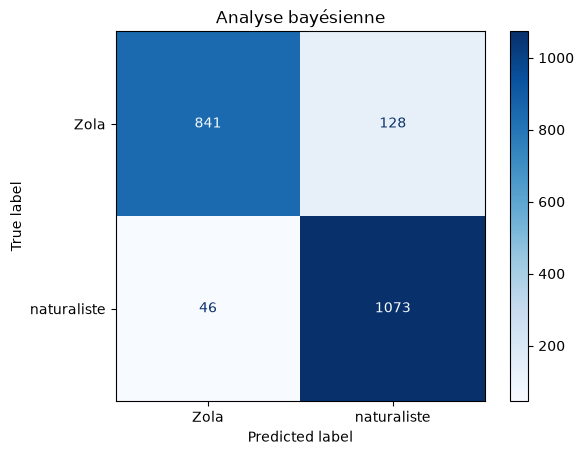

In [7]:
modele_bayes = MultinomialNB(alpha=1)

modele_bayes.fit(X_train_tfidf, y_train)

predictions = modele_bayes.predict(X_test_tfidf)

print(classification_report(y_test, predictions))

cm_bayesien = confusion_matrix(y_test, predictions)
print(cm_bayesien)

ConfusionMatrixDisplay(
    confusion_matrix=cm_bayesien,
    display_labels=modele_bayes.classes_
).plot(cmap="Blues")

plt.title("Analyse bayésienne")
plt.show()

### 8.2 Régression logistique

=== Régression logistique ===
              precision    recall  f1-score   support

        Zola      0.985     0.958     0.971       969
 naturaliste      0.964     0.987     0.976      1119

    accuracy                          0.974      2088
   macro avg      0.975     0.973     0.973      2088
weighted avg      0.974     0.974     0.974      2088

Matrice de confusion :
[[ 928   41]
 [  14 1105]]


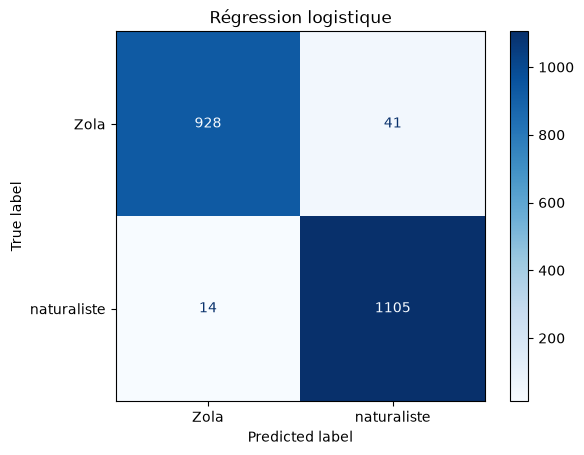

In [8]:
# Entraînement direct, sans Pipeline
modele_logistique = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

modele_logistique.fit(X_train_tfidf, y_train)

predictions_logistiques = modele_logistique.predict(X_test_tfidf)

print("=== Régression logistique ===")
print(classification_report(y_test, predictions_logistiques, digits=3))

cm_logistique = confusion_matrix(y_test, predictions_logistiques)
print("Matrice de confusion :")
print(cm_logistique)

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistique,
    display_labels=modele_logistique.classes_
).plot(cmap="Blues")

plt.title("Régression logistique")
plt.show()

In [9]:
print("Balanced accuracy :", balanced_accuracy_score(y_test,predictions_logistiques))

Balanced accuracy : 0.9725885839025888


### 8.3 Analyse discriminante linéaire après réduction SVD

L'analyse discriminante linéaire ne travaille pas directement sur une matrice TF-IDF creuse comportant plusieurs milliers de colonnes. On réduit donc d'abord la dimension avec `TruncatedSVD`, puis on standardise les composantes avant d'entraîner la LDA.

=== Analyse discriminante linéaire ===
Nombre de composantes SVD : 100
Variance expliquée cumulée par la SVD : 0.153
              precision    recall  f1-score   support

        Zola      0.971     0.974     0.973       969
 naturaliste      0.978     0.975     0.976      1119

    accuracy                          0.975      2088
   macro avg      0.974     0.975     0.974      2088
weighted avg      0.975     0.975     0.975      2088

Matrice de confusion :
[[ 944   25]
 [  28 1091]]


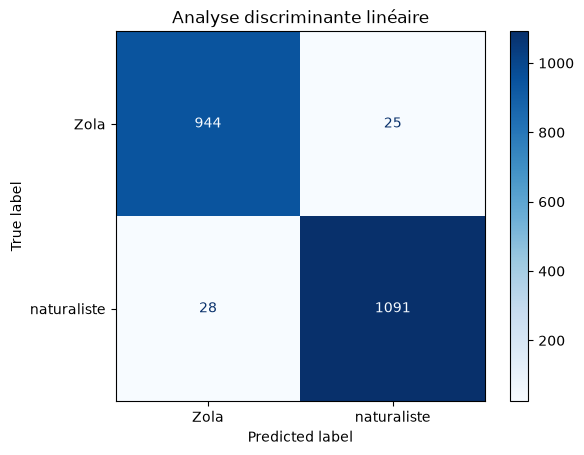

In [10]:
# Nombre de composantes compatible avec la taille réelle des données
n_composantes = min(
    100,
    X_train_tfidf.shape[0] - 1,
    X_train_tfidf.shape[1] - 1)

# Réduction de dimension
svd = TruncatedSVD(
    n_components=n_composantes,
    random_state=42)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

# Standardisation
scaler_lda = StandardScaler()
X_train_lda = scaler_lda.fit_transform(X_train_svd)
X_test_lda = scaler_lda.transform(X_test_svd)

# Analyse discriminante linéaire
modele_lda = LinearDiscriminantAnalysis(solver="svd")
modele_lda.fit(X_train_lda, y_train)

predictions_lda = modele_lda.predict(X_test_lda)

print("=== Analyse discriminante linéaire ===")
print(f"Nombre de composantes SVD : {n_composantes}")
print(
    "Variance expliquée cumulée par la SVD : "
    f"{svd.explained_variance_ratio_.sum():.3f}"
)
print(classification_report(y_test, predictions_lda, digits=3))

cm_lda = confusion_matrix(y_test, predictions_lda)
print("Matrice de confusion :")
print(cm_lda)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lda,
    display_labels=modele_lda.classes_
).plot(cmap="Blues")

plt.title("Analyse discriminante linéaire")
plt.show()


## 9. Comparaison des performances sur le corpus de test

Les résultats du corpus de test sont présentés après la sélection du modèle
par validation croisée. Ils constituent une évaluation complémentaire.

In [11]:
comparaison_modeles = pd.DataFrame({
    "modèle": [
        "Analyse bayésienne",
        "Régression logistique",
        "Analyse discriminante linéaire"
    ],

    "accuracy": [
        accuracy_score(y_test, predictions),
        accuracy_score(y_test, predictions_logistiques),
        accuracy_score(y_test, predictions_lda)
    ],

    "f1_macro": [
        f1_score(y_test, predictions, average="macro"),
        f1_score(y_test, predictions_logistiques, average="macro"),
        f1_score(y_test, predictions_lda, average="macro")
    ]
})

print("\nComparaison des modèles sur le jeu de test :")

comparaison_modeles.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)


Comparaison des modèles sur le jeu de test :


,modèle,accuracy,f1_macro
0,Analyse discriminante linéaire,0.974617,0.974490
1,Régression logistique,0.973659,0.973468
2,Analyse bayésienne,0.916667,0.915625


## 10. Évaluation finale au niveau des œuvres

Les probabilités des segments appartenant à une même œuvre sont moyennées
afin d'obtenir une prédiction unique par œuvre.

In [12]:
probabilites = modele_logistique.predict_proba(
    X_test_tfidf
)

classe_zola = list(
    modele_logistique.classes_
).index("Zola")

evaluation_oeuvres = df_test[
    ["source", "label"]
].copy()

evaluation_oeuvres["probabilite_zola"] = (
    probabilites[:, classe_zola]
)

resultats_oeuvres = (
    evaluation_oeuvres
    .groupby("source")
    .agg(
        label_reel=("label", "first"),
        probabilite_zola=(
            "probabilite_zola",
            "mean"
        )
    )
    .reset_index()
)

resultats_oeuvres["prediction"] = np.where(
    resultats_oeuvres["probabilite_zola"] >= 0.5,
    "Zola",
    "naturaliste"
)

print(
    classification_report(
        resultats_oeuvres["label_reel"],
        resultats_oeuvres["prediction"],
        digits=3
    )
)

resultats_oeuvres

              precision    recall  f1-score   support

        Zola      1.000     1.000     1.000         4
 naturaliste      1.000     1.000     1.000         9

    accuracy                          1.000        13
   macro avg      1.000     1.000     1.000        13
weighted avg      1.000     1.000     1.000        13



,source,label_reel,probabilite_zola,prediction
0,Edmond_de_Goncourt_La_Faustin.txt,naturaliste,0.143224,naturaliste
1,Guy_de_Maupassant_L_Âme_étrangère.txt,naturaliste,0.113974,naturaliste
2,Honoré_de_Balzac_Histoire_de_la_grandeur_et_de...,naturaliste,0.150944,naturaliste
3,J_H_Rosny_Nymphée.txt,naturaliste,0.128145,naturaliste
4,J_H_Rosny_aîné_Le_Jardin_de_Mary.txt,naturaliste,0.121162,naturaliste
5,Joris_Karl_Huysmans_En_ménage.txt,naturaliste,0.235472,naturaliste
6,Joris_Karl_Huysmans_En_route.txt,naturaliste,0.168327,naturaliste
7,Octave_Mirbeau_calvaire.txt,naturaliste,0.119378,naturaliste
8,Paul_de_Kock_Zizine.txt,naturaliste,0.064741,naturaliste
9,Émile_Zola_La_Conquête_de_Plassans.txt,Zola,0.769815,Zola


In [13]:
evaluation = df_test[["source", "label"]].copy()
evaluation["prediction"] = predictions_logistiques

performance_par_oeuvre = (
    evaluation
    .groupby("source")
    .apply(
        lambda groupe: pd.Series({
            "label_reel": groupe["label"].iloc[0],
            "n_segments": len(groupe),
            "accuracy_segments": (
                groupe["prediction"]
                == groupe["label"]
            ).mean(),
            "prediction_majoritaire": (
                groupe["prediction"]
                .value_counts()
                .idxmax()
            )
        }),
        include_groups=False
    )
    .reset_index()
)

print(performance_par_oeuvre)

print(
    "Accuracy moyenne par œuvre :",
    performance_par_oeuvre[
        "accuracy_segments"
    ].mean()
)

                                               source   label_reel  \
0                   Edmond_de_Goncourt_La_Faustin.txt  naturaliste   
1               Guy_de_Maupassant_L_Âme_étrangère.txt  naturaliste   
2   Honoré_de_Balzac_Histoire_de_la_grandeur_et_de...  naturaliste   
3                               J_H_Rosny_Nymphée.txt  naturaliste   
4                J_H_Rosny_aîné_Le_Jardin_de_Mary.txt  naturaliste   
5                   Joris_Karl_Huysmans_En_ménage.txt  naturaliste   
6                    Joris_Karl_Huysmans_En_route.txt  naturaliste   
7                         Octave_Mirbeau_calvaire.txt  naturaliste   
8                             Paul_de_Kock_Zizine.txt  naturaliste   
9              Émile_Zola_La_Conquête_de_Plassans.txt         Zola   
10                          Émile_Zola_La_Débâcle.txt         Zola   
11                             Émile_Zola_Le_Rêve.txt         Zola   
12        Émile_Zola_Son_Excellence_Eugène_Rougon.txt         Zola   

    n_segments  acc

## 11. Interprétation des modèles à partir du corpus d'entraînement

Cette section examine les paramètres appris par les modèles, sans tenir
compte de la fréquence des termes dans le corpus de test.

### 11.1 Termes caractéristiques selon Naive Bayes

In [14]:
classifieur = modele_bayes

mots = vectorizer.get_feature_names_out()
classes = classifieur.classes_

print("Ordre des classes :", classes)

# Différence des log-probabilités entre les deux classes
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats_mots = pd.DataFrame({
    "mot": mots,
    f"score_{classes[0]}": score_discriminant
})

# Mots les plus caractéristiques de la première classe
mots_classe_0 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=False
).head(30)

# Mots les plus caractéristiques de la deuxième classe
mots_classe_1 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=True
).head(30)

print(f"\nMots les plus caractéristiques de {classes[0]} :")
for _, ligne in mots_classe_0.iterrows():
    print(f"{ligne['mot']:<25} {ligne[f'score_{classes[0]}']:.3f}")

print(f"\nMots les plus caractéristiques de {classes[1]} :")
for _, ligne in mots_classe_1.iterrows():
    print(f"{ligne['mot']:<25} {-ligne[f'score_{classes[0]}']:.3f}")

Ordre des classes : ['Zola' 'naturaliste']

Mots les plus caractéristiques de Zola :
teuse                     2.459
la teuse                  2.431
vandeuvres                2.402
la faloise                2.314
faloise                   2.314
coron                     2.285
fontan                    2.236
labordette                2.228
insurgés                  2.178
mineurs                   2.037
zingueur                  2.027
paradou                   2.027
pecqueux                  2.015
virginie                  1.921
clientes                  1.881
lâchait                   1.877
le zingueur               1.867
murmura il                1.865
charcuterie               1.857
murmura elle              1.836
bonheur des               1.781
la charcuterie            1.770
achevait                  1.761
dut                       1.743
entêtait                  1.740
les insurgés              1.739
débandade                 1.731
universelle               1.726
flore              

### 11.2 Coefficients de la régression logistique

In [15]:
# Termes les plus discriminants de la régression logistique
termes_logistiques = vectorizer.get_feature_names_out()
classes_logistiques = modele_logistique.classes_

print("Ordre des classes :", classes_logistiques)

# En classification binaire :
# - coefficient positif  -> classe classes_[1]
# - coefficient négatif  -> classe classes_[0]
coefficients = modele_logistique.coef_[0]

importance_logistique = pd.DataFrame({
    "terme": termes_logistiques,
    "coefficient": coefficients
})

n = 30

termes_classe_0 = (
    importance_logistique
    .sort_values("coefficient", ascending=True)
    .head(n))

termes_classe_1 = (
    importance_logistique
    .sort_values("coefficient", ascending=False)
    .head(n))

print(f"\nTermes les plus associés à {classes_logistiques[0]} :")
for _, ligne in termes_classe_0.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")

print(f"\nTermes les plus associés à {classes_logistiques[1]} :")
for _, ligne in termes_classe_1.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")

Ordre des classes : ['Zola' 'naturaliste']

Termes les plus associés à Zola :
ça                             -4.5964
lorsque                        -4.2377
elle                           -3.2116
lorsqu                         -2.9348
avait                          -2.9223
très                           -2.7112
qu elle                        -2.6022
tandis que                     -2.4028
un instant                     -2.3882
murmura                        -2.2303
tandis                         -2.2264
dames                          -2.1776
un coup                        -2.1458
de nouveau                     -2.1108
ce pas                         -2.0974
au fond                        -2.0676
encore                         -2.0138
oncle                          -2.0116
eut un                         -1.9762
il avait                       -1.9494
cria                           -1.9322
simplement                     -1.8962
eut                            -1.8845
ce fut                   

## 12. Analyse post-hoc du corpus de test

Cette section examine les termes effectivement présents dans le corpus de
test. Elle est uniquement interprétative et n'est pas utilisée pour
modifier le prétraitement, sélectionner le modèle ou régler ses
hyperparamètres.

### 12.1 Présence et poids TF-IDF des termes dans le test

In [16]:
# Utilisation du TF-IDF commun
classifieur = modele_bayes

# Vocabulaire appris sur le train
termes = vectorizer.get_feature_names_out()

# Ordre réel des classes
classes = classifieur.classes_

print("Ordre des classes :", classes)

# Nombre d'extraits du test contenant chaque terme
presence_test = np.asarray((X_test_tfidf > 0).sum(axis=0)).ravel()

# Somme des poids TF-IDF de chaque terme dans le test
poids_tfidf_test = np.asarray(X_test_tfidf.sum(axis=0)).ravel()

# Score discriminant appris par Naive Bayes
# score positif : classe 0
# score négatif : classe 1
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats = pd.DataFrame({
    "terme": termes,
    "score_discriminant": score_discriminant,
    "nb_extraits_test": presence_test,
    "poids_tfidf_test": poids_tfidf_test
})

# On conserve uniquement les termes présents dans le test
resultats_test = resultats[
    resultats["nb_extraits_test"] > 0
].copy()

print(f"\nNombre de termes du vocabulaire présents dans le test : "
      f"{len(resultats_test)}")

Ordre des classes : ['Zola' 'naturaliste']

Nombre de termes du vocabulaire présents dans le test : 9946


### 12.2 Termes discriminants de Naive Bayes présents dans le test

In [17]:
n = 30

termes_classe_0 = (
    resultats_test
    .sort_values("score_discriminant", ascending=False)
    .head(n)
)

termes_classe_1 = (
    resultats_test
    .sort_values("score_discriminant", ascending=True)
    .head(n)
)

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[0]} :")

for _, ligne in termes_classe_0.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[1]} :")

for _, ligne in termes_classe_1.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={-ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}")


Termes présents dans le test les plus caractéristiques de Zola :
insurgés                  score=2.178  extraits=1
virginie                  score=1.921  extraits=9
clientes                  score=1.881  extraits=3
lâchait                   score=1.877  extraits=15
murmura il                score=1.865  extraits=86
charcuterie               score=1.857  extraits=2
murmura elle              score=1.836  extraits=48
bonheur des               score=1.781  extraits=3
achevait                  score=1.761  extraits=67
dut                       score=1.743  extraits=141
entêtait                  score=1.740  extraits=14
les insurgés              score=1.739  extraits=1
débandade                 score=1.731  extraits=25
universelle               score=1.726  extraits=9
flore                     score=1.699  extraits=9
ses jupes                 score=1.694  extraits=18
la goutte                 score=1.669  extraits=5
la fosse                  score=1.668  extraits=2
normande                 

### 12.3 Contribution lexicale globale dans le corpus de test

L'indicateur ci-dessous combine le caractère discriminant appris par
Naive Bayes avec le poids TF-IDF total du terme dans le corpus de test.

Il s'agit d'un indicateur descriptif global. Il ne représente pas une
explication locale exacte de chaque prédiction.

In [18]:
resultats_test["contribution_test"] = (
    resultats_test["score_discriminant"]
    * resultats_test["poids_tfidf_test"]
)

contributions_zola = (
    resultats_test
    .sort_values("contribution_test", ascending=False)
    .head(30)
)

contributions_naturalistes = (
    resultats_test
    .sort_values("contribution_test", ascending=True)
    .head(30)
)


print(contributions_zola[["terme", "contribution_test"]])
print(contributions_naturalistes[["terme", "contribution_test"]])

           terme  contribution_test
2771        elle          64.674291
5           abbé          49.207143
2897    empereur          30.856795
556        avait          25.374498
5339     lorsque          22.623066
7291     qu elle          20.252356
9733          ça          19.294355
5332      lorsqu          19.178553
8723  tandis que          14.681842
8721      tandis          13.775367
3369         eut          13.533130
9169  un instant          13.503308
3375      eut un          13.462207
6326       oncle          13.074815
4232         ils          12.712620
9145     un coup          12.251849
2663         dut          11.601191
8932     tout un          11.520921
1993  de nouveau          11.478945
1775       dames          11.406271
2879  elle était          11.404469
9414      venait          11.396216
4130      il eut          11.377713
4094    il avait          11.353979
3618       finit          11.252687
2377        dieu          11.154751
7821         rue          10